In [1]:
"""
@
Auteurs:        Jeffrey Jason Boekstaaf, Tim Paulus van Croimvort en Haydar Eryörük
Studentnummers: 500460365, 500916516 en 500910901
Datum:          20-03-2026
Vak:            Beroepsproject 3.4
Opleiding:      Toegepaste Wiskunde & Data Science
School:         Hogeschool van Amsterdam
"""
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# Hier wordt de testdata ingeladen.
data_test = pd.read_csv("data_test.csv")


In [2]:
# Haalt de Gradient Boosting classifier op uit de lokale map.
with open('pipelineGB.pkl', 'rb') as file:
    gradient_boosting_pipe = pickle.load(file)


In [3]:
# Op churn wordt de voorspelling gedaan en alle andere variabelen zijn X.
X = data_test.drop(columns = ['Churn'])
Y = data_test["Churn"]


In [4]:
# Uit de gridsearch zijn deze parameters als de beste samenstelling gekomen en daarom dienen zij hier aangepast te worden.
gradient_boosting_pipe.n_estimators = 3000
gradient_boosting_pipe.learning_rate = 1
gradient_boosting_pipe.max_depth = 10
#gradient_boosting_pipe.Pipeline.ModelGB.GradientBoostingClassifier(n_estimators = 2000, learning_rate = 0.1, max_depth = 10)
#gradient_boosting_pipe.set_params(n_estimators = 2000, learning_rate = 0.1, max_depth = 10)


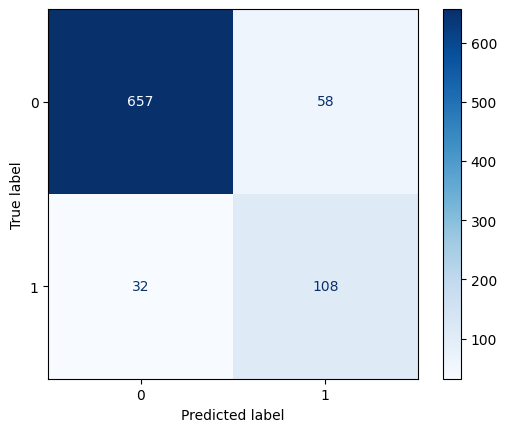

In [5]:
# Hier wordt de voorspelling gedaan op de X-variabelen van de test_data.
predicted = gradient_boosting_pipe.predict(X)
y_train = LabelEncoder().fit_transform(data_test['Churn'])

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_train, predicted, cmap = 'Blues')
plt.show()


Hier valt de confusion matrix af te lezen op de testdata. Er is te zien dat zowel de daadwerkelijke waarden van 0 en 1 met respectievelijk voorspelde waarden 0 en 1 de twee grootste groepen zijn. De twee kleinste groepen zijn de foute groepen.

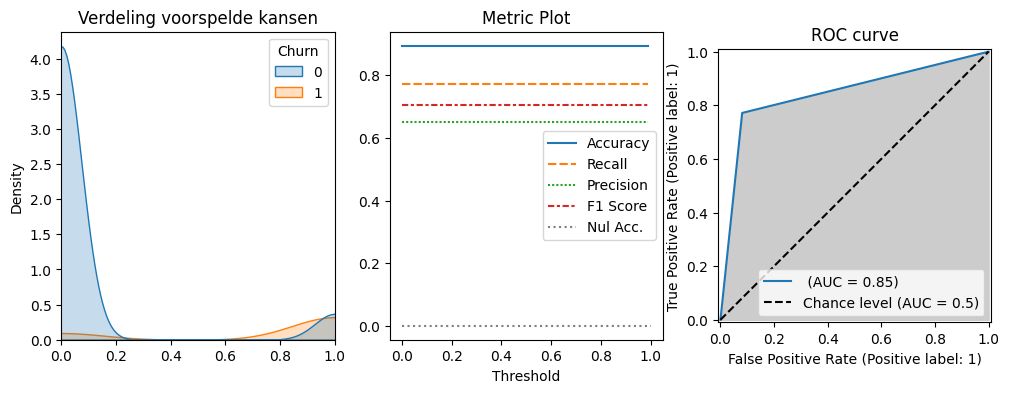

In [6]:
# Verdeling van de voorspelde kansen.
plt.figure(figsize = (12, 4))
plt.subplot(1, 3, 1)
sns.kdeplot(data_test, x = predicted[:], hue = 'Churn', fill = True)
plt.xlim(0, 1)
plt.title('Verdeling voorspelde kansen')

# Zet een classification report om in een rij van een dataframe
def make_row(cr):
    return {
        'Accuracy':  cr['accuracy'],
        'Recall':    cr['1']['recall'],
        'Precision': cr['1']['precision'],
        'F1 Score':  cr['1']['f1-score']
    }

thresholds = np.arange(0, 1, 0.01)
plot_data = pd.DataFrame([
    make_row(classification_report(
        y_train, 
        predicted[:] > t, 
        zero_division = True, 
        output_dict = True)) for t in thresholds])
plot_data.index = thresholds

# Metric plot
plt.subplot(1, 3, 2)
sns.lineplot(plot_data)
plt.plot([0, 1], [0, 0], 'k:', alpha = 0.5, label = 'Nul Acc.')
plt.xlabel('Threshold')
plt.legend()
plt.title('Metric Plot')

# ROC-curve
ax = plt.subplot(1, 3, 3)
roc = RocCurveDisplay.from_predictions(
    y_train, 
    predicted[:], 
    name = '', 
    plot_chance_level = True,
    ax = ax)
plt.fill_between(roc.fpr, roc.tpr, color = '0.8')
plt.title('ROC curve')
plt.show()


Hier zijn drie grafieken weergegeven die uitleggen hoe goed dit model werkt. Er is een auc-waarde van 0,84 gemeten en die zegt dat dit model goed voorspelt of de Churn-waarde 0 of 1 is. Dit is af te lezen in grafiek 3. In grafiek 1 is af te lezen de kansen van de churns en die later zijn omgezet in 0 of 1 als waarde van de churn. Het is logisch dat kansen meer richting de 0.0 de churn waarde 0 wordt en kansen richting 1.0 de churn waarde 1 wordt. In grafiek 2 zijn de waarden van de accuracy, recall, precision en F1-score af te lezen.

In [7]:
W = (((data_test['Seconds of Use'] / 60.0) * 0.2) + (data_test['Frequency of SMS'] * 0.07))
expected_profit = (1 - (0.25 * predicted)) * W
print("De winstverwachting is: €", (round(expected_profit.sum(), 2)), sep = "", end = ".")


De winstverwachting is: €17862.71.

In [8]:
# Hier worden de accuracy, f1, precision en recall scores berekend en gegeven.
acc = round(accuracy_score(y_train, predicted), 2)
rec = round(recall_score(y_train, predicted), 2)
pre = round(precision_score(y_train, predicted), 2)
fsco = round(f1_score(y_train, predicted), 2)
table = {"Name": ["Accuracy", "Recall", "Precision", "F1-score"],
        "Value": [acc, rec, pre, fsco]}
df = pd.DataFrame(table)
df


,Name,Value
0,Accuracy,0.89
1,Recall,0.77
2,Precision,0.65
3,F1-score,0.71
